# Randomised GC Content Reducer for Gene Block Design

In [2]:
"""
Module: Randomised GC content reducer
Author: Fabio Rodrigues
Version: 1.0

Description:
    This module provides a tool for reducing the GC content of coding DNA
    sequences by randomly replacing codons with synonymous alternatives, 
    with the aim of reducing GC content while preserving protein sequence.

    The aim is to make high-GC gene blocks easier to synthesise while
    preserving the encoded protein sequence and retaining some codon-level
    stochasticity.
"""

__author__ = "Fabio Rodrigues"
__version__ = "1.0"

# Randomised GC Content Reduction for Gene Block Synthesis

This notebook contains a small Python tool for reducing the GC content of coding DNA sequences through randomised synonymous codon replacement.

The tool was developed for high-GC gene blocks, where commercial synthesis can fail or become difficult due to excessive GC content and local sequence complexity. The function preserves the translated protein sequence, checks protein conservation after recoding, and compares global and local GC content before and after optimisation.

## Method note

The current implementation performs randomised synonymous codon selection at each amino acid position. This preserves the translated protein sequence while introducing codon-level stochasticity, avoiding the overuse of a single synonymous codon per amino acid.

The method is intended as a practical sequence-design aid, not as a full codon-optimisation platform.

## Limitations

- The current version uses random synonymous codon replacement and does not yet explicitly optimise codon usage for a target organism.
- GC reduction is stochastic, so repeated runs may produce different outputs.
- The tool does not yet screen for all synthesis-relevant motifs, such as restriction sites, repeats, homopolymers, or secondary-structure-prone regions.
- The current workflow is notebook-based and intended for exploratory use.

In [6]:
import random

import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm
from pathlib import Path

In [7]:
def gc_reducer_randomised(
    sequence_id: str = "sequence_id",
    dna_seq: str = "ACGTACGT",
    save_results_to: str = "my_folder",
    name_file: str = "my_file",
    save_it: str = "n",
):
    """
    Optimises a DNA sequence to reduce its GC content while preserving the 
    protein sequence.

    This function takes a DNA sequence as input, translates it into a protein 
    sequence using a reference codon table, and then reverse translates the
    protein sequence back into a DNA sequence using a randomised synonymous 
    codon selection strategy intended to reduce GC content. It then calculates 
    and reports the initial and final GC percentages, the percentage reduction 
    in GC content, and verifies if the protein sequence is conserved after the 
    optimisation. The results are printed to the console and optionally saved to
    a CSV file and visualised as bar and line plots.

    Args:
        sequence_id (str): A unique identifier for the DNA sequence. 
        This will be used in the output file names and plot titles.
        dna_seq (str): The DNA sequence to be optimised. It is crucial that
            this sequence is provided in the 5' to 3' orientation.
        save_results_to (str): The directory path where the output CSV file
            and PNG image(s) will be saved if `save_it` is 'y' or 'Y'.
        name_file (str): The base name for the output files (CSV and PNG).
            The function will append suffixes like '_data', '_bar', and '_GC_av'
            to this base name.
        save_it (str): A string indicating whether to save the results to a 
            file.
            Use 'y' or 'Y' to save, and any other value (e.g., 'n' or 'N') to 
            skip saving.

    Returns:
        pandas.DataFrame: A transposed DataFrame containing the sequence ID,
            the GC-content-reduced DNA sequence, the translated protein 
            sequence, the initial and final GC percentages, the percentage 
            reduction in GC content, and a boolean indicating if the protein 
            sequence was conserved. This DataFrame is also saved to a CSV file 
            if `save_it` is 'y' or 'Y'.

    Outputs (if save_it is 'y' or 'Y'):
        - A CSV file (named '{name_file}_data.csv') containing the transposed
          output data.
        - A bar plot (named '{name_file}_bar.png') showing the initial and
          final GC percentages.
        - A line plot (named '{name_file}_GC_av.png') showing the average GC
          content over 50-base pair windows for both the original and
          optimised DNA sequences.

    Example:
        >>> sequence_id = 'MySequence'
        >>> dna_seq = 'atgtcatcagcggtggagtgcaatgtc'
        >>> save_results_to = '/path/to/save/results/'
        >>> name_file = 'optimised_sequence'
        >>> save_it = 'y'
        >>> result_df = gc_reducer_randomised(sequence_id, 
        dna_seq, save_results_to, name_file, save_it)

        Sequence ID:  MySequence

        GC-content-reduced DNA sequence
        atgtcatcagcggtggagtgcaatgtc

        Translated protein
        MSSAVECNV

        Initial   GC%: 51.9
        Final     GC%: 44.4
        GC content reduced by  14.5 %

        Protein sequence conserved before and after optimisation:  True
        Files saved successfully"""

    # Standard codon table
    # This table can be replaced if a different genetic code is needed.

    codon_table = {
        'TTT': 'F', 'TTC': 'F', 'TTA': 'L', 'TTG': 'L', 'CTT': 'L',
        'CTC': 'L', 'CTA': 'L', 'CTG': 'L', 'ATT': 'I', 'ATC': 'I',
        'ATA': 'I', 'ATG': 'M', 'GTT': 'V', 'GTC': 'V', 'GTA': 'V',
        'GTG': 'V', 'TCT': 'S', 'TCC': 'S', 'TCA': 'S', 'TCG': 'S',
        'CCT': 'P', 'CCC': 'P', 'CCA': 'P', 'CCG': 'P', 'ACT': 'T',
        'ACC': 'T', 'ACA': 'T', 'ACG': 'T', 'GCT': 'A', 'GCC': 'A',
        'GCA': 'A', 'GCG': 'A', 'TAT': 'Y', 'TAC': 'Y', 'TAA': '*',
        'TAG': '*', 'CAT': 'H', 'CAC': 'H', 'CAA': 'Q', 'CAG': 'Q',
        'AAT': 'N', 'AAC': 'N', 'AAA': 'K', 'AAG': 'K', 'GAT': 'D',
        'GAC': 'D', 'GAA': 'E', 'GAG': 'E', 'TGT': 'C', 'TGC': 'C',
        'TGA': '*', 'TGG': 'W', 'CGT': 'R', 'CGC': 'R', 'CGA': 'R',
        'CGG': 'R', 'AGT': 'S', 'AGC': 'S', 'AGA': 'R', 'AGG': 'R',
        'GGT': 'G', 'GGC': 'G', 'GGA': 'G', 'GGG': 'G'}

    # Reverse codon table: amino acid -> list of synonymous codons
    # This will be used for randomised synonymous codon selection.

    codon_table_rev = {}
    for codon, amino_acid in codon_table.items():
        codon_table_rev.setdefault(amino_acid, []).append(codon)

    ############################################################################
    # Translates the original DNA into a protein sequence.

    dna_seq = dna_seq.upper()

    # Input validation

    valid_bases = {'A', 'C', 'G', 'T'}

    if len(dna_seq) % 3 != 0:
        raise ValueError("DNA sequence length must be divisible by 3.")

    if not set(dna_seq).issubset(valid_bases):
        invalid_bases = set(dna_seq) - valid_bases
        raise ValueError(f"DNA sequence contains invalid bases: {invalid_bases}")

    def translate_dna_to_protein(dna_seq, codon_table):
        protein_seq = ""

        for i in tqdm(range(0, len(dna_seq), 3), desc="Translating DNA"):
            codon = dna_seq[i : i + 3]
            amino_acid = codon_table.get(codon, "")  # '' = unknown codon
            protein_seq += amino_acid

        return protein_seq

    ############################################################################
    # Reverse translates the protein sequence into DNA.
    # A synonymous codon is selected randomly at each amino acid position.

    def reduce_gc_randomised(protein_seq, codon_table_rev):
        optimised_dna = ""

        for amino_acid in protein_seq:
            random_codon = random.choice(codon_table_rev[amino_acid])
            optimised_dna += random_codon

        return optimised_dna


    ############################################################################
    # Generates the protein and DNA sequences defined above
    protein_seq = translate_dna_to_protein(dna_seq, codon_table)
    if '*' in protein_seq[:-1]:
        print("Warning: internal stop codon detected.")
    optimised_dna = reduce_gc_randomised(protein_seq, codon_table_rev)

    # Calculates the GC% before and after optimisation, and the % variation
    gc_initial = round(
        (dna_seq.count("C") + dna_seq.count("G")) / len(dna_seq) * 100, 1
    )
    gc_final = round(
        (optimised_dna.count("C") + optimised_dna.count("G"))
        / len(optimised_dna)
        * 100,
        1,
    )
    delta_gc = round(gc_initial - gc_final, 1)

    # Translates the optimised, GC% reduced DNA sequence
    # into protein sequence
    #
    protein_seq_opt = translate_dna_to_protein(optimised_dna, codon_table)

    ############################################################################
    # Quality control: verifies if the protein sequence remains
    # identical before and after the optimisation

    qc = protein_seq == protein_seq_opt

    output_data = {
        "Sequence ID: ": [sequence_id],
        "GC-content-reduced DNA sequence": [optimised_dna],
        "Translated protein": [protein_seq],
        "Initial  GC%:": [gc_initial],
        "Final    GC%:": [gc_final],
        "GC reduction relative to initial GC / %": [delta_gc],
        "Protein sequence conserved before and after optimisation: ": [qc],
    }

    df_output = pd.DataFrame(output_data)
    df_output_t = df_output.transpose()

    ############################################################################
    # Saves data as csv
    def save_file_out(file_name, save):
        if save == "Y" or save == "y":
            save_folder = Path(save_results_to)
            save_folder.mkdir(parents=True, exist_ok=True)

            save_path = save_folder / f"{file_name}.csv"
            df_output_t.to_csv(save_path)

            print("CSV file saved successfully")
        else:
            print("No files were saved")
        return df_output_t

    ############################################################################

    # Prints the results
    print("Sequence ID: ", sequence_id)
    print()
    print("GC-content-reduced DNA sequence")
    print(optimised_dna)
    print()
    print("Translated protein")
    print(protein_seq)
    print()
    print("Initial GC%:", gc_initial)
    print("Final GC%:", gc_final)
    print("GC content reduced by ", delta_gc, "percentage points")
    print()
    print()
    print("Protein sequence conserved before and after optimisation: ", qc)
    print()
    ############################################################################

    # Generates a bar chart with the calculated GC%
    def save_bar_fig(file_name, save):
        labels = ["Initial GC%", "Final GC%"]
        data = [gc_initial, gc_final]

        fig, ax = plt.subplots()
        ax.bar(labels, data, color="steelblue", edgecolor="k")
        ax.set_ylabel("GC%")

        ax.set_title(f"{sequence_id} GC% reduction")

        ax.text(s=f"{gc_initial} %", x=-0.05, y=gc_initial + 1, c="k")

        ax.text(s=f"{gc_final} %", x=0.95, y=gc_final + 1, c="k")

        ax.set_ylim(0, gc_initial + 10)

        # Saves figure as PNG
        if save == "Y" or save == "y":
            save_folder = Path(save_results_to)
            save_folder.mkdir(parents=True, exist_ok=True)
        
            save_path = save_folder / f"{file_name}.png"
        
            fig.savefig(
                save_path,
                dpi=300,
                facecolor="w",
                edgecolor="w",
                bbox_inches="tight",
            )
    
            print("Bar plot saved successfully")

    plt.show()
    print()

    ############################################################################
    # Table that gives a score of 1 to G/C and 0 to A/T

    score_table = {"C": "1", "G": "1", "A": "0", "T": "0"}

    # Window size used to calculate local GC content
    window_size = 50

    ############################################################################
    # Converts a DNA sequence into local GC% values using fixed-size windows

    def calculate_gc_windows(dna_sequence, score_table, window_size):
        scores = str.maketrans(score_table)
        score_string = dna_sequence.translate(scores)

        avg_list = []
        rangex = []

        for i in tqdm(
            range(0, len(score_string), window_size),
            desc="Calculating local GC averages",
        ):
            chunk = score_string[i : i + window_size]
            average = sum(int(char) for char in chunk) / len(chunk) * 100

            avg_list.append(average)
            rangex.append(i + len(chunk))

        return avg_list, rangex

    ############################################################################
    # Calculates local GC averages for original and optimised DNA sequences

    avg_list, rangex = calculate_gc_windows(dna_seq, score_table, window_size)

    avg_list_opt, rangex_opt = calculate_gc_windows(
        optimised_dna, score_table, window_size
    )

    ############################################################################
    ############################################################################
    # This makes a graph showing the average GC% for each window

    def save_gc_av_fig(file_name, save):
        fig, ax = plt.subplots()

        ax.plot(rangex, avg_list, label="Original DNA")
        ax.plot(rangex, avg_list_opt, label="Optimised DNA")

        ax.set_xlabel("Base pairs")
        ax.set_ylabel(f"Average GC% ({window_size} base segments)")
        ax.set_xticks(range(0, len(dna_seq) + 1, window_size))
        ax.set_title(f"{sequence_id} average GC content")
        ax.legend()
        ax.set_ylim(0, 109)
        ax.set_xscale("linear")

        # Saves figure as PNG
        if save == "Y" or save == "y":
            save_folder = Path(save_results_to)
            save_folder.mkdir(parents=True, exist_ok=True)

            save_path = save_folder / f"{file_name}.png"

            fig.savefig(
                save_path, dpi=300, 
                facecolor="w", 
                edgecolor="w", 
                bbox_inches="tight"
            )

            print("Average GC plot saved successfully")

        plt.show()

    ############################################################################
    save_file_out(name_file + "_data", save_it)
    save_bar_fig(name_file + "_bar", save_it)
    save_gc_av_fig(name_file + "_GC_av", save_it)

    return df_output_t


################################################################################

# Function block for reference
# Add the sequence name - It will be added to the graphs' title
# sequence_id   = 'Hygromycin'

# Add DNA sequence to be optimised, in 5' -> 3' orientation.
# dna_seq       = ('atgtcatcagcggtggagtgcaatgtcgcgagatcctggccgcgctgctcgacgggga')

# Add path to where the files should be saved
# save_results_to = (r"'/path/to/save/results/'")

# Add file name
# name_file     = 'Hygro_res_refac'

# Save file? Type 'y' or 'n'
# save_it       = 'n'

# ##############################################################################
# GC_reducer_tool(sequence_id,
#                 dna_seq,
#                 save_results_to,
#                 name_file,
#                 save_it)

Translating DNA:   0%|          | 0/342 [00:00<?, ?it/s]

Translating DNA:   0%|          | 0/342 [00:00<?, ?it/s]

Sequence ID:  Hygromycin

GC-content-reduced DNA sequence
ATGAGCTCAGCGGTCGAATGTAATGTTGTGACCCAAGAATCGTTGTTACTGTTGGATAGAATTGATTCCGATGATTCCTACGCGTCCCTACGAAACGACCAAGAATTTTGGGAACCCCTCGCTCGGCGCGCACTGGAGGAGCTCGGCTTACCGGTCCCACCGGTCTTGCGAGTCCCTGGGGAATCAACAAATCCAGTACTTGTAGGTGAGCCCGGCCCCGTCATCAAGCTCTTCGGAGAACATTGGTGCGGGCCCGAATCGCTGGCGTCAGAAAGTGAAGCATATGCTGTTCTTGCGGATGCTCCGGTTCCTGTACCGCGACTGCTAGGAAGGGGTGAATTGAGGCCCGGGACCGGGGCTTGGCCATGGCCTTACCTTGTTATGTCGAGGATGACAGGGACCACGTGGCGATCCGCAATGGACGGCACGACAGACCGTAATGCACTTCTTGCTCTTGCCCGTGAACTTGGTCGGGTTTTAGGACGACTACATCGTGTACCTCTGACGGGCAACACAGTACTAACCCCTCACAGTGAAGTCTTTCCAGAGTTGTTAAGGGAGAGGCGCGCTGCGACCGTGGAAGATCATAGAGGATGGGGATACCTTTCTCCCCGCCTTCTCGATCGACTTGAAGATTGGTTGCCCGATGTTGACACTCTCTTGGCCGGGAGAGAACCACGATTCGTTCATGGAGACCTACATGGCACAAACATTTTCGTGGATTTAGCTGCGACCGAGGTAACGGGTATTGTCGATTTCACCGACGTCTATGCAGGAGATTCTCGCTACTCACTTGTACAGTTGCATTTAAACGCTTTCAGGGGGGACCGAGAGATACTAGCCGCCCTTCTTGACGGAGCCCAATGGAAGAGGACCGAGGATTTCGCAAGGGAGCTACTGGCCTTCACATTCCTTCATGACTTCGAGGTGTTTGAGGAGACC

Calculating local GC averages:   0%|          | 0/21 [00:00<?, ?it/s]

Calculating local GC averages:   0%|          | 0/21 [00:00<?, ?it/s]

No files were saved


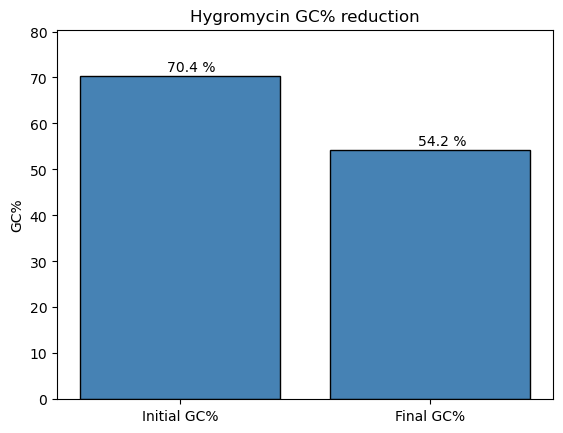

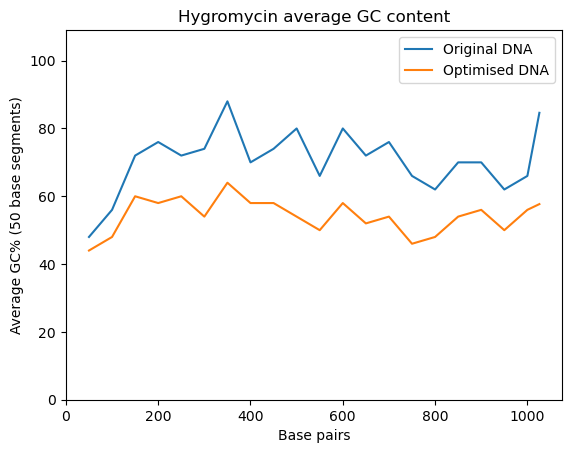

,0
Sequence ID:,Hygromycin
GC-content-reduced DNA sequence,ATGAGCTCAGCGGTCGAATGTAATGTTGTGACCCAAGAATCGTTGT...
Translated protein,MSSAVECNVVTQESLLLLDRIDSDDSYASLRNDQEFWEPLARRALE...
Initial GC%:,70.4
Final GC%:,54.2
GC reduction relative to initial GC / %,16.2
Protein sequence conserved before and after optimisation:,True


In [8]:
# Add the sequence name - it will be added to the graph titles
sequence_id = "Hygromycin"

# Add DNA sequence to be optimised, in 5' -> 3' orientation
dna_seq = ("atgtcatcagcggtggagtgcaatgtcgtgacacaagaatccctgttacttctcgaccgtattgatt"
           "cggatgattcctacgcgagcctgcggaacgaccaggaattctgggagccgctggcccgccgagccct"
           "ggaggagctcgggctgccggtgccgccggtgctgcgggtgcccggcgagagcaccaaccccgtactg"
           "gtcggcgagcccggcccggtgatcaagctgttcggcgagcactggtgcggtccggagagcctcgcgt"
           "cggagtcggaggcgtacgcggtcctggcggacgccccggtgccggtgccccgcctcctcggccgcgg"
           "cgagctgcggcccggcaccggagcctggccgtggccctacctggtgatgagccggatgaccggcacc"
           "acctggcggtccgcgatggacggcacgaccgaccggaacgcgctgctcgccctggcccgcgaactcg"
           "gccgggtgctcggccggctgcacagggtgccgctgaccgggaacaccgtgctcaccccccattccga"
           "ggtcttcccggaactgctgcgggaacgccgcgcggcgaccgtcgaggaccaccgcgggtggggctac"
           "ctctcgccccggctgctggaccgcctggaggactggctgccggacgtggacacgctgctggccggcc"
           "gcgaaccccggttcgtccacggcgacctgcacgggaccaacatcttcgtggacctggccgcgaccga"
           "ggtcaccgggatcgtcgacttcaccgacgtctatgcgggagactcccgctacagcctggtgcaactg"
           "catctcaacgccttccggggcgaccgcgagatcctggccgcgctgctcgacggggcgcagtggaagc"
           "ggaccgaggacttcgcccgcgaactgctcgccttcaccttcctgcacgacttcgaggtgttcgagga"
           "gaccccgctggatctctccggcttcaccgatccggaggaactggcgcagttcctctgggggccgccg"
           "gacaccgcccccggcgcctga")

# Add path to where the files should be saved
save_results_to = "results"

# Add file name
name_file = "Hygro_res_refac"

# Save file? Type 'y' or 'n'
save_it = "n"

# Run function
result_df = gc_reducer_randomised(
    sequence_id, 
    dna_seq, 
    save_results_to, 
    name_file, 
    save_it
)

result_df